In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [8]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import scorecardpy as sc
import xgboost as xgb

In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

In [10]:
import shap
import matplotlib.pyplot as plt

In [3]:
home_credit = pd.read_parquet("hf://datasets/jlh/home-credit/data/train-00000-of-00001-e68d01965482ae18.parquet")
home_credit.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
home_credit.shape

(307511, 122)

### Feature Selection Using IV value

In [5]:
### Using Informatioin Value
df = home_credit.copy()
df = df.drop(columns=["SK_ID_CURR"])
bins = sc.woebin(df, y="TARGET")

[INFO] creating woe binning ...


/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individuall

>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
ORGANIZATION_TYPE
>>> Continue the binning process?
1: yes 
2: no


/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .stack().replace('missing', np.nan) \
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .stack().replace('missing', np.nan) \
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

Binning on 307511 rows and 121 columns in 00:01:53


/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future 

In [6]:
iv_values = {var: bin_data['total_iv'].iloc[0] for var, bin_data in bins.items()}
selected_vars = [var for var, iv in iv_values.items() if iv >= 0.03]

In [9]:
print("Selected Variables: ", selected_vars)

Selected Variables:  ['NAME_EDUCATION_TYPE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT', 'LIVINGAREA_MODE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'ELEVATORS_AVG', 'AMT_GOODS_PRICE', 'ELEVATORS_MODE', 'EXT_SOURCE_2', 'APARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'FLOORSMAX_AVG', 'EXT_SOURCE_1', 'ELEVATORS_MEDI', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT_W_CITY', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'REG_CITY_NOT_WORK_CITY', 'OCCUPATION_TYPE', 'AMT_CREDIT', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'APARTMENTS_MODE', 'EXT_SOURCE_3', 'LIVINGAREA_AVG', 'APARTMENTS_AVG', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'TOTALAREA_MODE', 'CODE_GENDER']


In [10]:
len(selected_vars)

32

In [7]:
df_selected = df[selected_vars + ["TARGET"]]

In [12]:
df_selected.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   NAME_EDUCATION_TYPE          307511 non-null  object 
 1   FLAG_EMP_PHONE               307511 non-null  int64  
 2   REGION_RATING_CLIENT         307511 non-null  int64  
 3   LIVINGAREA_MODE              153161 non-null  float64
 4   DAYS_BIRTH                   307511 non-null  int64  
 5   DAYS_EMPLOYED                307511 non-null  int64  
 6   ELEVATORS_AVG                143620 non-null  float64
 7   AMT_GOODS_PRICE              307233 non-null  float64
 8   ELEVATORS_MODE               143620 non-null  float64
 9   EXT_SOURCE_2                 306851 non-null  float64
 10  APARTMENTS_MEDI              151450 non-null  float64
 11  LIVINGAREA_MEDI              153161 non-null  float64
 12  FLOORSMAX_AVG                154491 non-null  float64
 13 

In [13]:
xna_rows = df_selected[df_selected.isin(['XNA']).any(axis=1)]
len(xna_rows)

55378

In [8]:
extreme_days = df_selected[(df_selected['DAYS_EMPLOYED'] == 365243) & (df_selected.isin(['XNA']).any(axis=1))]
len(extreme_days)

55374

In [15]:
miss_rows = df_selected.isna().sum().sum()
miss_rows

2362070

In [9]:
float_var = df_selected.select_dtypes(include=[np.float64]).columns
float_var = df_selected[float_var]
float_var.describe()

,REGION_POPULATION_RELATIVE,EXT_SOURCE_2,APARTMENTS_AVG,FLOORSMAX_AVG,LIVINGAREA_MODE,FLOORSMAX_MODE,EXT_SOURCE_3,FLOORSMAX_MEDI,APARTMENTS_MODE,AMT_CREDIT,LIVINGAREA_AVG,ELEVATORS_AVG,ELEVATORS_MODE,LIVINGAREA_MEDI,DAYS_LAST_PHONE_CHANGE,EXT_SOURCE_1,TOTALAREA_MODE,ELEVATORS_MEDI,AMT_GOODS_PRICE,APARTMENTS_MEDI
count,307511.000000,3.068510e+05,151450.00000,154491.000000,153161.000000,154491.000000,246546.000000,154491.000000,151450.000000,3.075110e+05,153161.000000,143620.000000,143620.000000,153161.000000,307510.000000,134133.000000,159080.000000,143620.000000,3.072330e+05,151450.000000
mean,0.020868,5.143927e-01,0.11744,0.226282,0.105975,0.222315,0.510853,0.225897,0.114231,5.990260e+05,0.107399,0.078942,0.074490,0.108607,-962.858788,0.502130,0.102547,0.078078,5.383962e+05,0.117850
std,0.013831,1.910602e-01,0.10824,0.144641,0.111845,0.143709,0.194844,0.145067,0.107936,4.024908e+05,0.110565,0.134576,0.132256,0.112260,826.808487,0.211062,0.107462,0.134467,3.694465e+05,0.109076
min,0.000290,8.173617e-08,0.00000,0.000000,0.000000,0.000000,0.000527,0.000000,0.000000,4.500000e+04,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.014568,0.000000,0.000000,4.050000e+04,0.000000
25%,0.010006,3.924574e-01,0.05770,0.166700,0.042700,0.166700,0.370650,0.166700,0.052500,2.700000e+05,0.045300,0.000000,0.000000,0.045700,-1570.000000,0.334007,0.041200,0.000000,2.385000e+05,0.058300
50%,0.018850,5.659614e-01,0.08760,0.166700,0.073100,0.166700,0.535276,0.166700,0.084000,5.135310e+05,0.074500,0.000000,0.000000,0.074900,-757.000000,0.505998,0.068800,0.000000,4.500000e+05,0.086400
75%,0.028663,6.636171e-01,0.14850,0.333300,0.125200,0.333300,0.669057,0.333300,0.143900,8.086500e+05,0.129900,0.120000,0.120800,0.130300,-274.000000,0.675053,0.127600,0.120000,6.795000e+05,0.148900
max,0.072508,8.549997e-01,1.00000,1.000000,1.000000,1.000000,0.896010,1.000000,1.000000,4.050000e+06,1.000000,1.000000,1.000000,1.000000,0.000000,0.962693,1.000000,1.000000,4.050000e+06,1.000000


In [10]:
int_var = df_selected.select_dtypes(include=[np.int64]).columns
int_var = df_selected[int_var]
int_var.describe()

,DAYS_BIRTH,DAYS_EMPLOYED,REG_CITY_NOT_WORK_CITY,FLAG_EMP_PHONE,REGION_RATING_CLIENT_W_CITY,DAYS_ID_PUBLISH,REGION_RATING_CLIENT,TARGET
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,-16036.995067,63815.045904,0.230454,0.819889,2.031521,-2994.202373,2.052463,0.080729
std,4363.988632,141275.766519,0.421124,0.384280,0.502737,1509.450419,0.509034,0.272419
min,-25229.000000,-17912.000000,0.000000,0.000000,1.000000,-7197.000000,1.000000,0.000000
25%,-19682.000000,-2760.000000,0.000000,1.000000,2.000000,-4299.000000,2.000000,0.000000
50%,-15750.000000,-1213.000000,0.000000,1.000000,2.000000,-3254.000000,2.000000,0.000000
75%,-12413.000000,-289.000000,0.000000,1.000000,2.000000,-1720.000000,2.000000,0.000000
max,-7489.000000,365243.000000,1.000000,1.000000,3.000000,0.000000,3.000000,1.000000


In [11]:
### remove extreme values and XNA values
df_selected = df_selected[(df_selected['DAYS_EMPLOYED'] != 365243) & (~df_selected.isin(['XNA']).any(axis=1))]
df_selected.shape

(252133, 33)

In [19]:
df_selected.TARGET.value_counts()

TARGET
0    230298
1     21835
Name: count, dtype: int64

### Dataset split

In [11]:
df_selected = pd.read_csv('/Users/yuxianggao/Desktop/df_selected.csv')

In [12]:
#### split training and test
X = df_selected.drop(columns=['TARGET'])
y = df_selected['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
numerical_vars = df_selected.select_dtypes(include=[np.float64, np.int64]).columns
cat_vars = df_selected.select_dtypes(include=[object]).columns

In [14]:
numerical_vars = [var for var in numerical_vars if var != 'TARGET']

In [15]:
### preprocessing before smote
### re-sample the training data

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values
    ('scaler', StandardScaler())                 # Scale numerical features
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-hot encode categorical features
])

preprocessor_before_smote = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_vars),  # Leave numerical as is for SMOTE
        ('cat', cat_transformer, cat_vars)  # Encode categorical
    ]
)

In [16]:
X_train_encoded = preprocessor_before_smote.fit_transform(X_train)

smote = SMOTE(random_state=42)


X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)
X_train_resampled = X_train_resampled.toarray()

### Logistic CV

In [17]:
X_test_encoded = preprocessor_before_smote.transform(X_test)
X_test_encoded

<61503x119 sparse matrix of type '<class 'numpy.float64'>'
	with 1968096 stored elements in Compressed Sparse Row format>

In [ ]:
### Logistic Regression
pipeline = Pipeline(steps=[
    ('classifier', LogisticRegressionCV(cv=5, penalty='l2'))
])

pipeline.fit(X_train_resampled, y_train_resampled)

X_test_encoded = preprocessor_before_smote.transform(X_test)
y_pred = pipeline.predict(X_test_encoded)

y_pred_proba = pipeline.predict_proba(X_test_encoded)  # Probabilities


print(f'AUC:{roc_auc_score(y_test, y_pred_proba[:,1])}')
print(f'Recall:{recall_score(y_test, y_pred)}')

/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/yuxianggao/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

AUC:0.7371623776796408
Recall:0.6643766417458072


### XGBOOST

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'scale_pos_weight': [1, 2, 5]  # Adjust weight for class imbalance
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1
)

grid_search_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb_model = grid_search_xgb.best_estimator_

# Evaluate the best model
y_pred_best = best_xgb_model.predict(X_test_encoded)
recall_best = recall_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, best_xgb_model.predict_proba(X_test_encoded)[:,1])
print("Recall:", recall_best)
print("AUC:", auc_best)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


: 

### MLP 

In [9]:
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

In [16]:
class MLP(nn.Module):
    
    def __init__(self, num_features, hidden_size1, hidden_size2, num_classes):
        super(MLP, self).__init__()

        # 1st hidden layer
        self.linear_1 = nn.Linear(num_features, hidden_size1)
        # 2nd hidden layer
        self.linear_2 = nn.Linear(hidden_size1, hidden_size2)
        # output layer
        self.linear_out = nn.Linear(hidden_size2, num_classes)

    def forward(self, x):
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        logits = self.linear_out(x)
        probas = torch.sigmoid(logits)
        return probas

# Hyperparameters
num_features = X_train_resampled.shape[1]
hidden_size1 = 128
hidden_size2 = 64
num_classes = 1

### 

# create model
mlp_model = MLP(num_features, hidden_size1, hidden_size2, num_classes)

# define loss
criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# convert dataset to torch tensors
x_train_tensor = torch.tensor(X_train_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test_encoded.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# create data loader?
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

### train the model
# epoch: 训练轮次, batch_size: 每次训练的样本数
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

num_epochs = 100
for epoch in range(num_epochs):
    epoch_loss = 0
    mlp_model.train()  # Set model to training mode
    for X_batch, y_batch in train_loader:
        # X_batch, y_batch = X_batch.to(), y_batch

        # Forward pass
        outputs = mlp_model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        epoch_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/100], Loss: 3592.9855
Epoch [2/100], Loss: 2703.8317
Epoch [3/100], Loss: 2420.8486
Epoch [4/100], Loss: 2282.8268
Epoch [5/100], Loss: 2203.9424
Epoch [6/100], Loss: 2142.8635
Epoch [7/100], Loss: 2089.4473
Epoch [8/100], Loss: 2042.9154
Epoch [9/100], Loss: 2007.9656
Epoch [10/100], Loss: 1976.0821
Epoch [11/100], Loss: 1943.8187
Epoch [12/100], Loss: 1918.3393
Epoch [13/100], Loss: 1897.7419
Epoch [14/100], Loss: 1870.5803
Epoch [15/100], Loss: 1848.5123
Epoch [16/100], Loss: 1829.5264
Epoch [17/100], Loss: 1810.3367
Epoch [18/100], Loss: 1795.1607
Epoch [19/100], Loss: 1777.0654
Epoch [20/100], Loss: 1765.4997
Epoch [21/100], Loss: 1753.0665
Epoch [22/100], Loss: 1742.1051
Epoch [23/100], Loss: 1726.9875
Epoch [24/100], Loss: 1716.6653
Epoch [25/100], Loss: 1707.8547
Epoch [26/100], Loss: 1698.7612
Epoch [27/100], Loss: 1687.6558
Epoch [28/100], Loss: 1680.4305
Epoch [29/100], Loss: 1670.6041
Epoch [30/100], Loss: 1664.0339
Epoch [31/100], Loss: 1655.9754
Epoch [32/100], L

In [17]:
### train the model
# epoch: 训练轮次, batch_size: 每次训练的样本数


### test set
mlp_model.eval()
with torch.no_grad():
    prediction = mlp_model(x_test_tensor)
    predicted_class = (prediction.squeeze() > 0.5)
    print(predicted_class)

prediction = prediction.numpy()

print(f"Prediction for [0.7, 0.6]: {predicted_class} (0 represents Pass, 1 represents Fail)")
print(f'auc: {roc_auc_score(y_test, prediction)}')
print(f'recall: {recall_score(y_test, predicted_class)}')

tensor([False, False,  True,  ..., False, False, False])
Prediction for [0.7, 0.6]: tensor([False, False,  True,  ..., False, False, False]) (0 represents Pass, 1 represents Fail)
auc: 0.6573723336378838
recall: 0.2828854314002829


### Due to time limitation, I used the MLP model from Sklearn and used Grid Search CV to find the model with best performance. 

### MLP Usign Grid Search CV

In [40]:
# mlp = MLPClassifier(activation='relu', solver='adam', random_state=42)
# mlp.fit(X_train_resampled, y_train_resampled)

In [41]:
# y_pred = mlp.predict(X_test_encoded)
# test_auc = roc_auc_score(y_test, y_pred)
# train_auc = roc_auc_score(y_train_resampled, mlp.predict(X_train_resampled))
# confusion_matrix(y_test, y_pred)

In [42]:
# print(f'Test AUC: {test_auc}')
# print(f'Train AUC: {train_auc}')
# print(f'Recall: {recall_score(y_test, y_pred)}')

In [21]:
### Using Grid Search CV
mlp = MLPClassifier(random_state=42)

param_grid = {
    'hidden_layer_sizes':[(20,), (50,)],
    'alpha':[1,5,10],
    'learning_rate_init':[0.001, 0.01],
    'solver':['adam'],
    'early_stopping': [True]
}

grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, scoring='roc_auc', cv=3)
grid_search.fit(X_train_resampled, y_train_resampled)

best_model = grid_search.best_estimator_

In [46]:
y_proba = best_model.predict_proba(X_test_encoded)[:, 1]
y_pred = best_model.predict(X_test_encoded)
test_auc = roc_auc_score(y_test, y_proba)
train_auc = roc_auc_score(y_train_resampled, best_model.predict(X_train_resampled))

print(f'Test AUC: {test_auc}')
print(f'Train AUC: {train_auc}')
print(f'Recall: {recall_score(y_test, y_pred)}')

Test AUC: 0.7382468237592921
Train AUC: 0.7010617692321299
Recall: 0.6714487775308143


In [22]:
accuracy = best_model.score(X_test_encoded, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.678340893940133


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

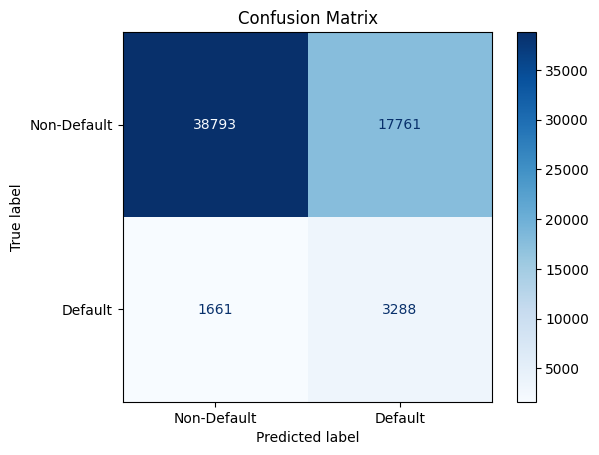

In [39]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Default", "Default"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
